In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.exceptions import ConvergenceWarning
import warnings

## 1 - Análise dos Dados

Com o intuito de entender melhor os dados utilizados, farei uma breve análise exploratória dos dados.

In [2]:
data_train = pd.read_csv('data/conjunto_de_treinamento.csv')
display(data_train.shape)
display(data_train.head())

(20000, 42)

,id_solicitante,produto_solicitado,dia_vencimento,forma_envio_solicitacao,tipo_endereco,sexo,idade,estado_civil,qtde_dependentes,grau_instrucao,...,possui_telefone_trabalho,codigo_area_telefone_trabalho,meses_no_trabalho,profissao,ocupacao,profissao_companheiro,grau_instrucao_companheiro,local_onde_reside,local_onde_trabalha,inadimplente
0,1,1,10,presencial,1,M,85,2,0,0,...,N,,0,9.0,1.0,0.0,0.0,600.0,600.0,0
1,2,1,25,internet,1,F,38,1,0,0,...,N,,0,2.0,5.0,NaN,NaN,492.0,492.0,0
2,3,1,20,internet,1,F,37,2,0,0,...,N,,0,NaN,NaN,NaN,NaN,450.0,450.0,1
3,4,1,20,internet,1,M,37,1,1,0,...,Y,54,0,9.0,2.0,NaN,NaN,932.0,932.0,1
4,5,7,1,internet,1,F,51,1,3,0,...,N,,0,9.0,5.0,NaN,NaN,440.0,440.0,1


In [3]:
display(data_train.describe())

,id_solicitante,produto_solicitado,dia_vencimento,tipo_endereco,idade,estado_civil,qtde_dependentes,grau_instrucao,nacionalidade,tipo_residencia,...,valor_patrimonio_pessoal,possui_carro,meses_no_trabalho,profissao,ocupacao,profissao_companheiro,grau_instrucao_companheiro,local_onde_reside,local_onde_trabalha,inadimplente
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.0,20000.000000,19464.000000,...,2.000000e+04,20000.000000,20000.000000,16903.000000,17022.000000,8486.000000,7140.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,1.284350,13.147250,1.006350,42.352500,2.120850,0.666400,0.0,0.961600,1.261303,...,2.095614e+03,0.339050,0.008900,8.045081,2.533310,3.708107,0.288095,581.295250,581.295250,0.500000
std,5773.647028,1.008239,6.748507,0.079435,14.930177,1.332004,1.236725,0.0,0.202305,0.883580,...,4.403344e+04,0.473399,0.388881,3.210790,1.532765,5.181241,0.944339,227.369798,227.369798,0.500013
min,1.000000,1.000000,1.000000,1.000000,7.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,105.000000,105.000000,0.000000
25%,5000.750000,1.000000,10.000000,1.000000,31.000000,1.000000,0.000000,0.0,1.000000,1.000000,...,0.000000e+00,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,444.000000,444.000000,0.000000
50%,10000.500000,1.000000,10.000000,1.000000,40.000000,2.000000,0.000000,0.0,1.000000,1.000000,...,0.000000e+00,0.000000,0.000000,9.000000,2.000000,0.000000,0.000000,596.000000,596.000000,0.500000
75%,15000.250000,1.000000,20.000000,1.000000,52.000000,2.000000,1.000000,0.0,1.000000,1.000000,...,0.000000e+00,1.000000,0.000000,9.000000,4.000000,11.000000,0.000000,728.000000,728.000000,1.000000
max,20000.000000,7.000000,25.000000,2.000000,106.000000,7.000000,53.000000,0.0,2.000000,5.000000,...,6.000000e+06,1.000000,32.000000,17.000000,5.000000,17.000000,5.000000,999.000000,999.000000,1.000000


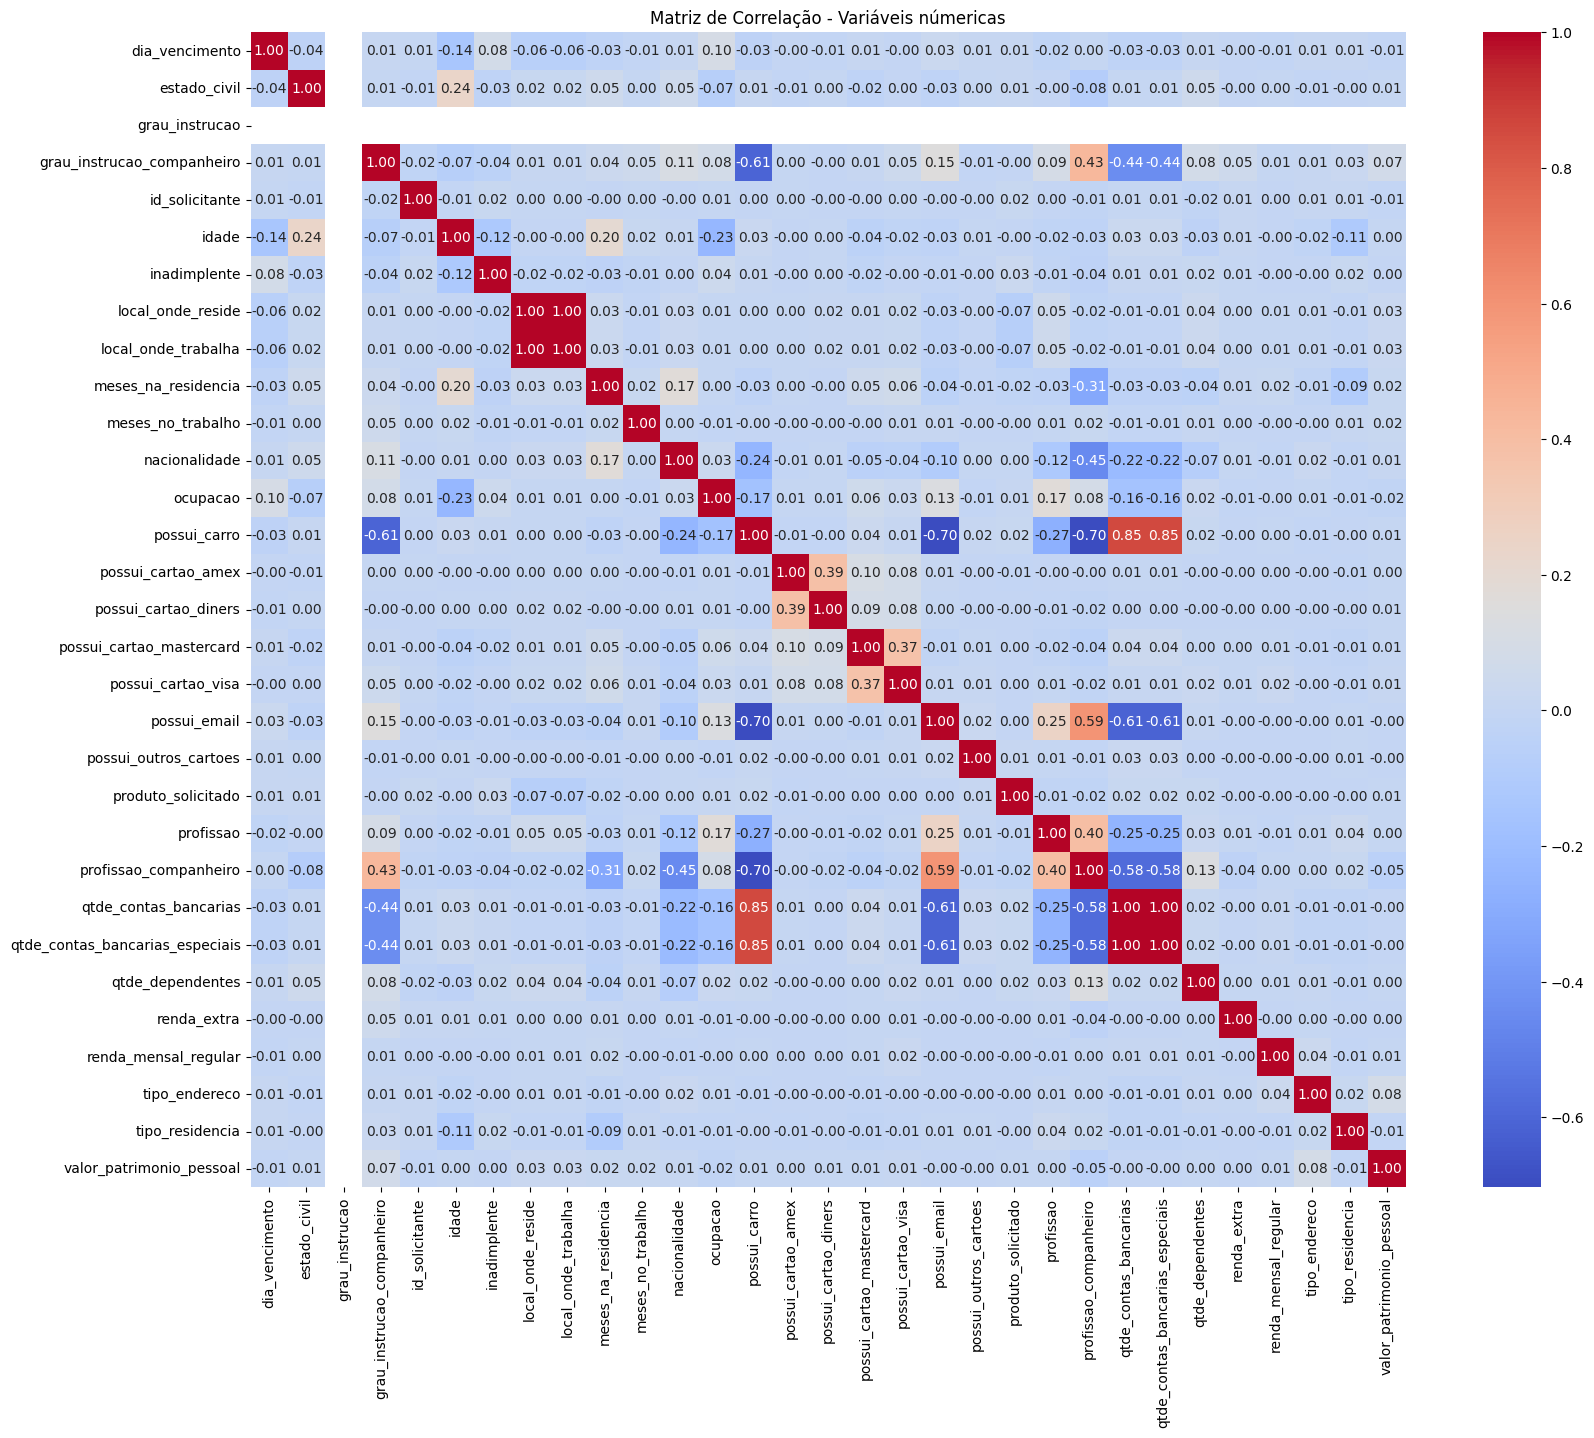

In [4]:
numeric_cols = data_train.select_dtypes(include=[np.number]).columns
correlation_matrix = data_train[numeric_cols].corr()
correlation_matrix = correlation_matrix.reindex(sorted(correlation_matrix.columns), axis=0)
correlation_matrix = correlation_matrix.reindex(sorted(correlation_matrix.columns), axis=1)
plt.figure(figsize=(20, 15))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlação - Variáveis númericas')
plt.show()

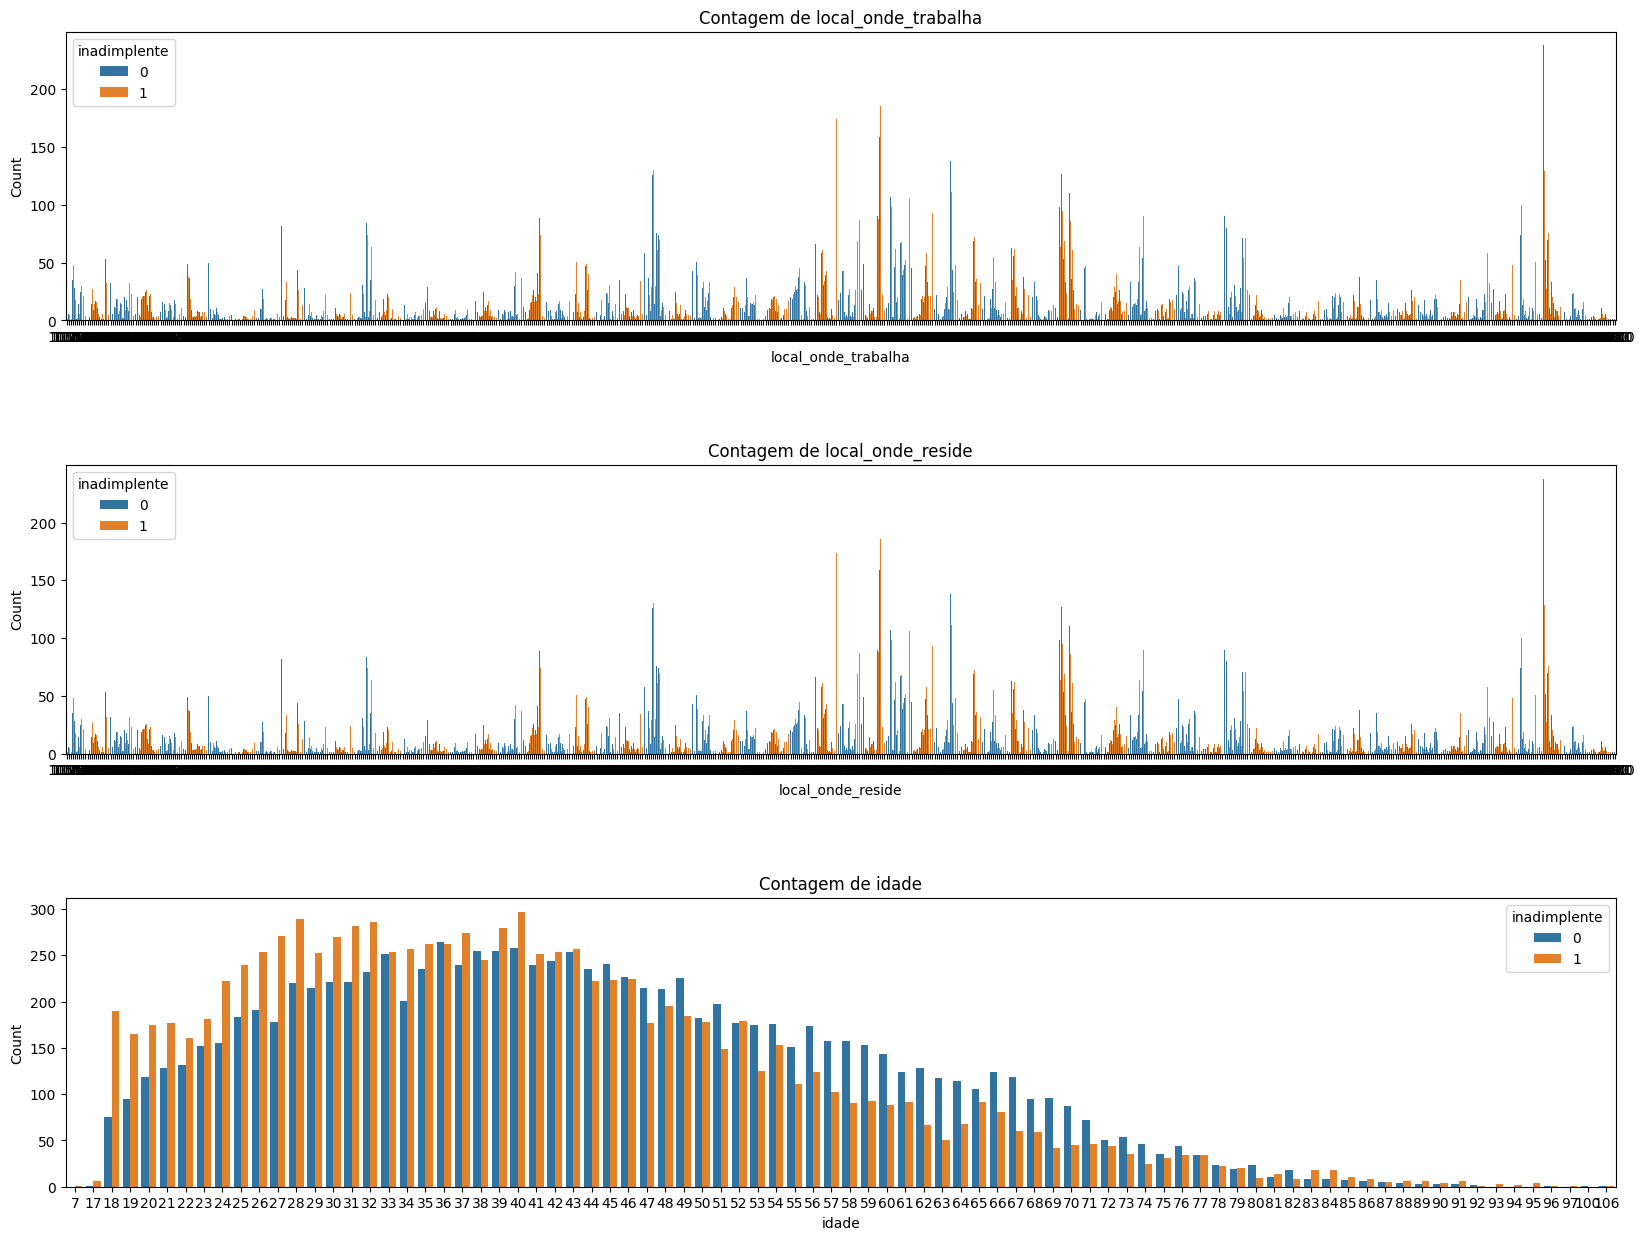

In [5]:
numeric_cols = data_train.select_dtypes(include=[np.number]).columns
choosen_cols = [col for col in data_train.columns.to_list()
                if col not in ['id_solicitante', 'inadimplente']]
num_cols_per_row = 1
choosen_cols = ['local_onde_trabalha', 'local_onde_reside', 'idade']
num_rows = len(choosen_cols) // num_cols_per_row + (len(choosen_cols) % num_cols_per_row > 0)

# Criação da figura
plt.figure(figsize=(20, num_rows * 5))
custom_palette = {np.int64(0): '#0d9ff', np.int64(1): '#FF2600'}
for i, col in enumerate(choosen_cols, 1):
    plt.subplot(num_rows, num_cols_per_row, i)
    if col == 'idade':
        n_bins = 100
    else:
        n_bins = 300
    # sns.histplot(data=data_train, x=col, hue ='inadimplente', bins=n_bins)
    sns.countplot(data=data_train, x=col, hue ='inadimplente')
    plt.title(f'Contagem de {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.subplots_adjust(hspace=0.5)
plt.show()


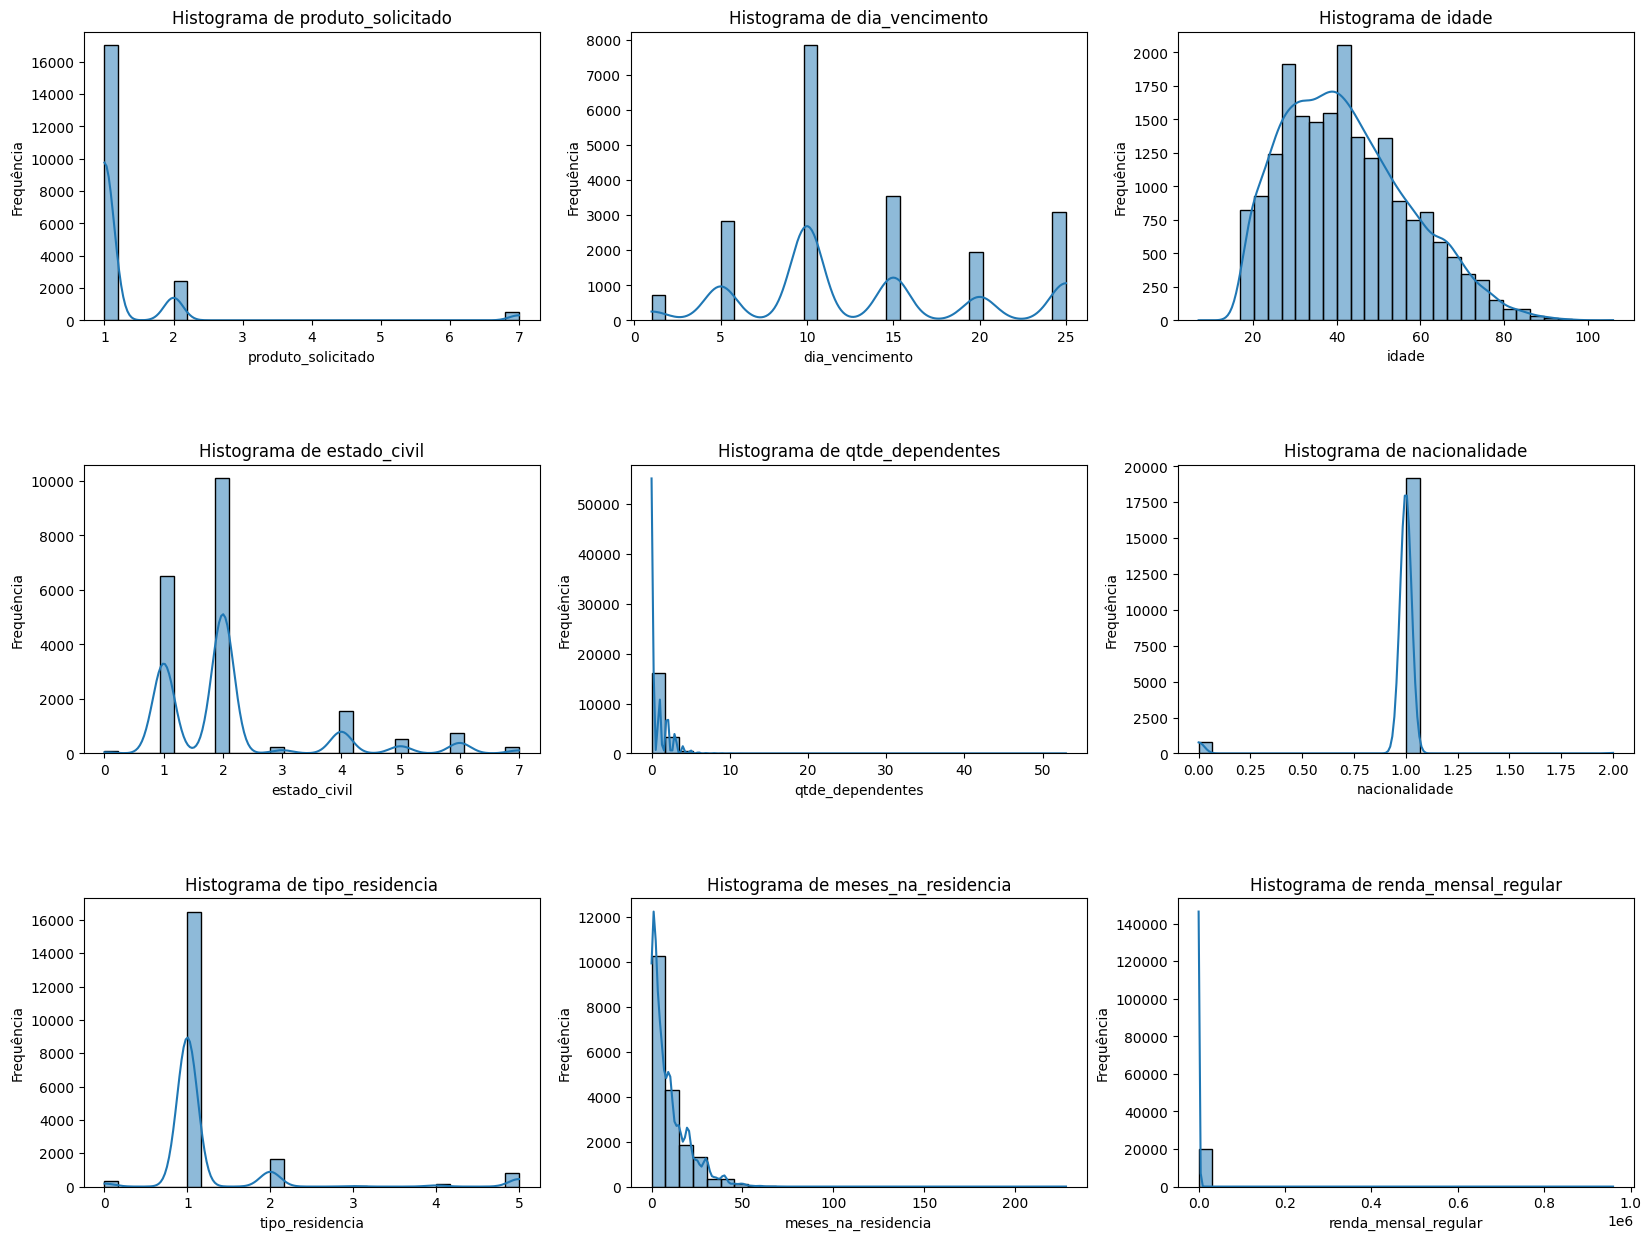

In [6]:
choosen_cols = ['produto_solicitado', 'dia_vencimento', 'idade', 'estado_civil', 'qtde_dependentes', 'nacionalidade',
                'tipo_residencia', 'meses_na_residencia', 'renda_mensal_regular']

num_cols_per_row = 3
num_rows = len(choosen_cols) // num_cols_per_row + (len(choosen_cols) % num_cols_per_row > 0)


plt.figure(figsize=(20, num_rows * 5))
for i, col in enumerate(choosen_cols, 1):
    plt.subplot(num_rows, num_cols_per_row, i)
    sns.histplot(data_train[col], bins=30, kde=True)
    plt.title(f'Histograma de {col}')
    plt.xlabel(col)
    plt.ylabel('Frequência')

plt.subplots_adjust(hspace=0.5)
plt.show()

Aparentemente, a idade, local de trabalho e de residência são fatores que demonstram boa correlação com a variável alvo.

## 2 - Pré-processamento dos Dados

Para evitar retrabalho, carregarei os dados de treinamento e previsão juntos em um único dataframe e aplicarei as alterações necessárias para pré-processamento dos dados. Depois, dividirei os dados novamente para testar o modelo.

In [7]:
data_test = pd.read_csv('data/conjunto_de_teste.csv')
data_train = pd.read_csv('data/conjunto_de_treinamento.csv')
id_solicitante_kaggle = data_test['id_solicitante'] 
splitting_idx = len(data_train)
display(data_test.head())

,id_solicitante,produto_solicitado,dia_vencimento,forma_envio_solicitacao,tipo_endereco,sexo,idade,estado_civil,qtde_dependentes,grau_instrucao,...,estado_onde_trabalha,possui_telefone_trabalho,codigo_area_telefone_trabalho,meses_no_trabalho,profissao,ocupacao,profissao_companheiro,grau_instrucao_companheiro,local_onde_reside,local_onde_trabalha
0,20001,1,25,presencial,1,M,37,2,0,0,...,,N,,0,0.0,0.0,0.0,0.0,384.0,384.0
1,20002,1,10,internet,1,F,31,2,0,0,...,RJ,N,,0,9.0,5.0,NaN,NaN,275.0,275.0
2,20003,1,10,internet,1,F,18,2,0,0,...,RS,N,,0,9.0,2.0,NaN,NaN,948.0,948.0
3,20004,1,10,presencial,1,F,55,2,0,0,...,,N,,0,9.0,1.0,0.0,0.0,581.0,581.0
4,20005,1,10,presencial,1,F,55,1,0,0,...,,N,,0,0.0,1.0,0.0,0.0,573.0,573.0


In [8]:
id_solicitante = data_test['id_solicitante']
data = pd.concat([data_train, data_test], ignore_index=True)

### 2.1 - Preenchendo valores nulos

In [9]:
sum_nulls = data.isnull().sum()
column_with_null = sum_nulls[sum_nulls > 0]
column_with_null.drop('inadimplente', inplace=True)
display(column_with_null.sort_index())

grau_instrucao_companheiro    16070
meses_na_residencia            1812
ocupacao                       3668
profissao                      3859
profissao_companheiro         14401
tipo_residencia                 661
dtype: int64

In [10]:
def summarize_null(df: pd.DataFrame, column: str, dist_plot: bool):
    if dist_plot:
        sns.displot(df[column], kde=True)
    else:
        sns.countplot(data=df, x=column, hue ='inadimplente')
    print(f'Contagem de valores únicos: {df[column].nunique()}')
    uniq = df[column].unique()
    uniq.sort()
    print(f'Valores únicos: {uniq}')
    print(f'Contagem de valores nulos: {df[column].isnull().sum()} -> {(df[column].isnull().sum()/len(df[column].index))*100}% dos dados')

#### 2.1.1 - Grau instrução companheiro e profissão companheiro
- Devido ao alto percentual de valores nulos nessas colunas (64% e 57%), decidi não utilizar na predição e serão removidos do conjunto de dados.

Contagem de valores únicos: 6
Valores únicos: [ 0.  1.  2.  3.  4.  5. nan]
Contagem de valores nulos: 16070 -> 64.28% dos dados


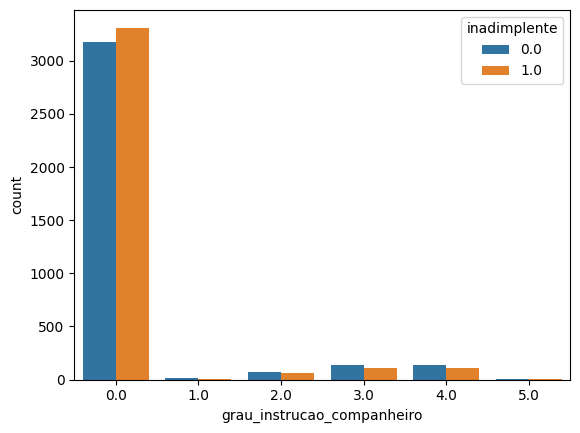

In [11]:
summarize_null(data, 'grau_instrucao_companheiro', dist_plot=False)

Contagem de valores únicos: 16
Valores únicos: [ 0.  1.  2.  3.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. nan]
Contagem de valores nulos: 14401 -> 57.604% dos dados


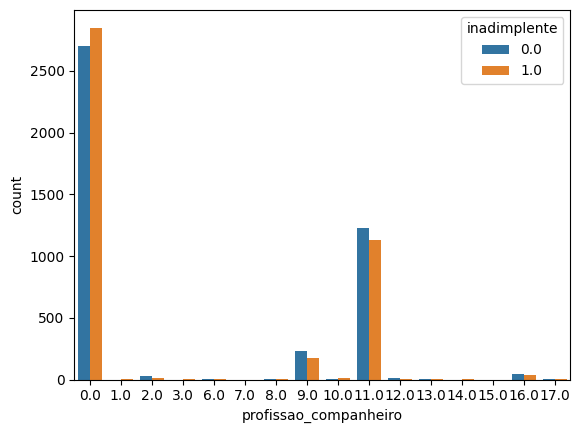

In [12]:
summarize_null(data, 'profissao_companheiro', dist_plot=False)

In [13]:
data = data.drop(columns=['grau_instrucao_companheiro', 'profissao_companheiro'])

#### 2.1.2 - Tipo de residência e meses na residência


- Para o tipo de residência, usarei a moda (1) para preencher os valores nulos já que a disparidade é muito grande entre os outros tipos.
- Para a variável meses na residência, usarei a média agrupada pelo tipo de residência.


Contagem de valores únicos: 6
Valores únicos: [ 0.  1.  2.  3.  4.  5. nan]
Contagem de valores nulos: 661 -> 2.644% dos dados


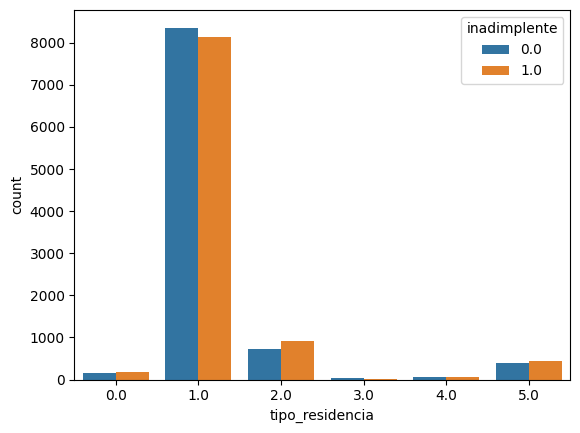

In [14]:
summarize_null(data, 'tipo_residencia', dist_plot=False)

Contagem de valores únicos: 80
Valores únicos: [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  67.  68.  70.  71.
  72.  78.  80.  81.  84.  89.  96. 100. 200. 228.  nan]
Contagem de valores nulos: 1812 -> 7.248% dos dados


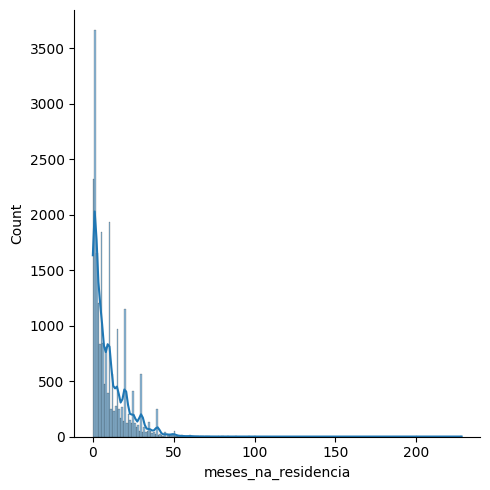

In [15]:
summarize_null(data, 'meses_na_residencia', dist_plot=True)

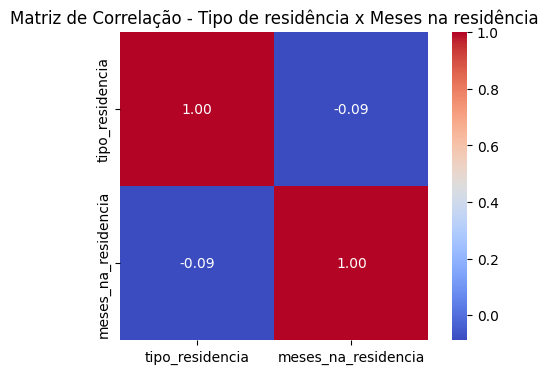

In [16]:
choosen_cols = ['tipo_residencia','meses_na_residencia']
correlation_matrix = data[choosen_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlação - Tipo de residência x Meses na residência')
plt.show()

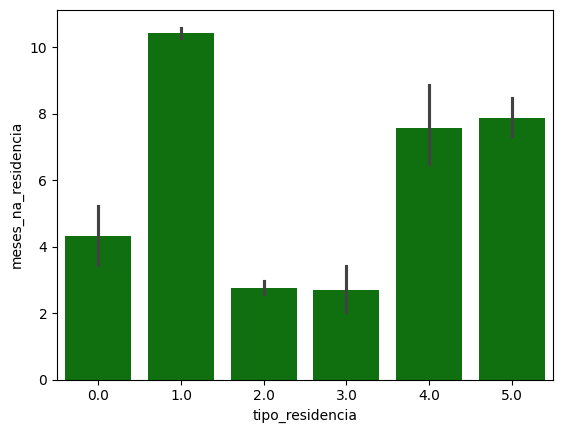

In [17]:
sns.barplot(x="tipo_residencia", y="meses_na_residencia", data=data, color='green')
plt.show()

In [18]:
data['tipo_residencia'] = data['tipo_residencia'].fillna(1)

avg_time = data.groupby('tipo_residencia')['meses_na_residencia'].mean()
data['meses_na_residencia'] = data['meses_na_residencia'].fillna(data['tipo_residencia'].map(avg_time))

#### 2.1.3 - Profissão e ocupação

- A variável de profissão parece estar muito mal distribuída. Além disso, a variável possui uma forte correlação com a variável ocupação e portanto, utilizarei apenas a segunda, que parece estar melhor distribuída.
- Para preencher os valores nulos de ocupação, utilizarei a moda (2).

Contagem de valores únicos: 19
Valores únicos: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. nan]
Contagem de valores nulos: 3859 -> 15.436% dos dados


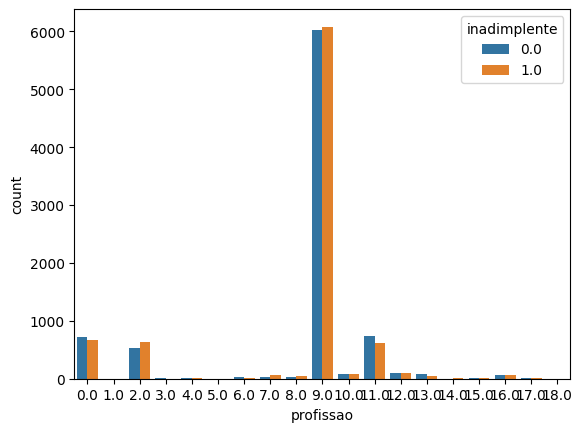

In [19]:
summarize_null(data, 'profissao', dist_plot=False)

Contagem de valores únicos: 6
Valores únicos: [ 0.  1.  2.  3.  4.  5. nan]
Contagem de valores nulos: 3668 -> 14.671999999999999% dos dados


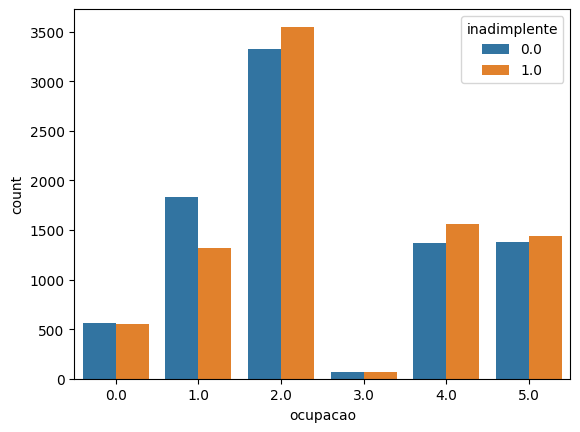

In [20]:
summarize_null(data, 'ocupacao', dist_plot=False)

In [21]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(data['profissao'], data['ocupacao'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared:", chi2)
print("p-value:", p)

Chi-squared: 18658.652699689716
p-value: 0.0


In [22]:
data = data.drop(columns=['profissao'])
data['ocupacao'] = data['ocupacao'].fillna(2)

In [23]:
sum_nulls = data.isnull().sum()
column_with_null = sum_nulls[sum_nulls > 0]
column_with_null.drop('inadimplente', inplace=True)
display(column_with_null.sort_index())

Series([], dtype: int64)

- Podemos verificar que todos os valores nulos foram preenchidos. 

### 2.2 - Preenchendo strings vazias

In [24]:
empty_counts = data.map(lambda x: isinstance(x, str) and x.strip() == '').sum()

filtered_counts = empty_counts[empty_counts > 0]

display(filtered_counts.sort_index())

codigo_area_telefone_residencial     4353
codigo_area_telefone_trabalho       18186
estado_onde_nasceu                   1032
estado_onde_trabalha                17006
sexo                                   11
dtype: int64

In [25]:
def summarize_empty(df: pd.DataFrame, column: str, dist_plot: bool):
    plt.figure(figsize=(10, 4))
    if dist_plot:
        sns.displot(df[column], kde=True)
    else:
        sns.countplot(data=df, x=column, hue ='inadimplente')
    print(f'Contagem de valores únicos: {df[column].nunique()}')
    uniq = df[column].unique()
    uniq.sort()
    print(f'Valores únicos: {uniq}')
    empty_count = df[column].apply(lambda x: x.strip() == '').sum()
    print(f'Contagem de valores vazios: {empty_count} -> {(empty_count / len(df[column].index)) * 100}% dos dados')


- A variável codigo_area_telefone_trabalho apresenta alto índice (>50%) de "vazia", portanto será removida.
- A variável codigo_area_telefone_residencial apresenta forte correlação com localidade_onde_reside

#### 2.2.1 - Sexo
- A variável sexo será preenchida conforme o padrão das outras não informadas, com o valor 'N'. 

Contagem de valores únicos: 4
Valores únicos: [' ' 'F' 'M' 'N']
Contagem de valores vazios: 11 -> 0.044000000000000004% dos dados


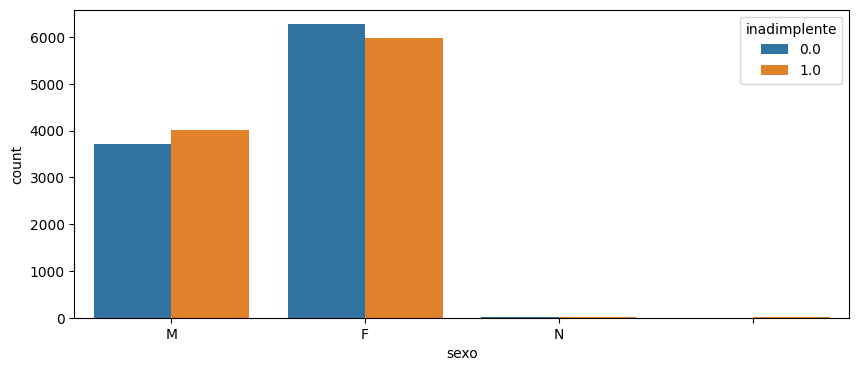

In [26]:
summarize_empty(data, 'sexo', False)

In [27]:
data.loc[data['sexo'].str.strip() == '', 'sexo'] = 'N'

### 2.2.2 - Estado onde nasceu e estado onde trabalha
- A variável estado_onde_nasceu será preenchida conforme o padrão dos campos não identificador, com valor 'XX'.
- As variáveis estado_onde_reside e estado_onde_trabalha possuem uma correlação forte. Como a variável de estado_onde_trabalha apresenta alto índice (>50%) de "vazia", será removida e considerarei apenas o estado_onde_reside que não apresenta valores nulos.

Contagem de valores únicos: 28
Valores únicos: [' ' 'AC' 'AL' 'AM' 'AP' 'BA' 'CE' 'DF' 'ES' 'GO' 'MA' 'MG' 'MS' 'MT' 'PA'
 'PB' 'PE' 'PI' 'PR' 'RJ' 'RN' 'RO' 'RR' 'RS' 'SC' 'SE' 'SP' 'TO']
Contagem de valores vazios: 1032 -> 4.128% dos dados


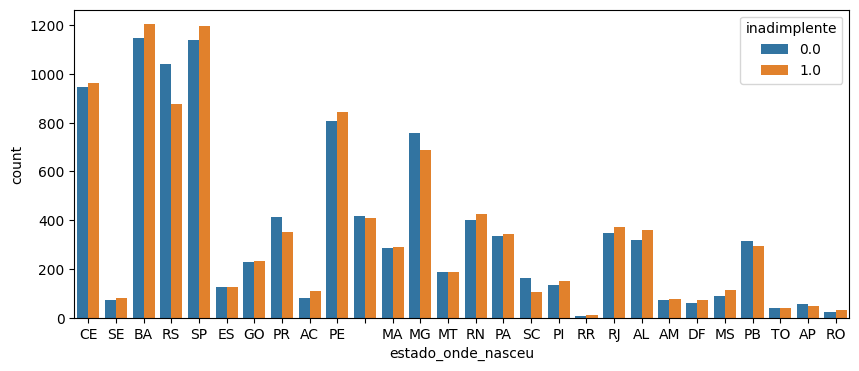

In [28]:
summarize_empty(data, 'estado_onde_nasceu', False)

Contagem de valores únicos: 27
Valores únicos: ['AC' 'AL' 'AM' 'AP' 'BA' 'CE' 'DF' 'ES' 'GO' 'MA' 'MG' 'MS' 'MT' 'PA'
 'PB' 'PE' 'PI' 'PR' 'RJ' 'RN' 'RO' 'RR' 'RS' 'SC' 'SE' 'SP' 'TO']
Contagem de valores vazios: 0 -> 0.0% dos dados


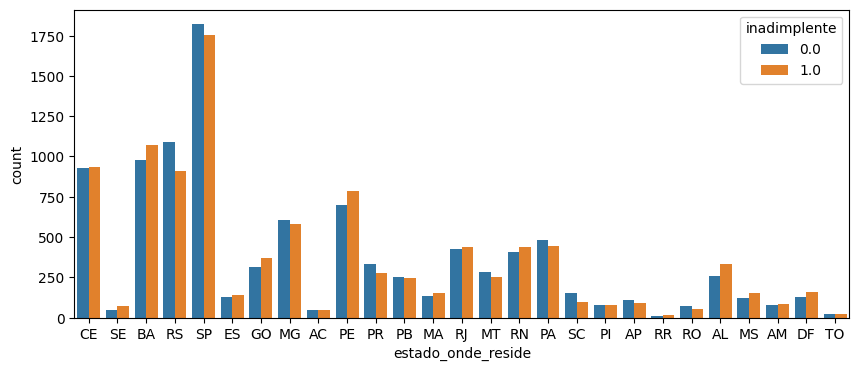

In [29]:
summarize_empty(data, 'estado_onde_reside', False)

Contagem de valores únicos: 28
Valores únicos: [' ' 'AC' 'AL' 'AM' 'AP' 'BA' 'CE' 'DF' 'ES' 'GO' 'MA' 'MG' 'MS' 'MT' 'PA'
 'PB' 'PE' 'PI' 'PR' 'RJ' 'RN' 'RO' 'RR' 'RS' 'SC' 'SE' 'SP' 'TO']
Contagem de valores vazios: 17006 -> 68.024% dos dados


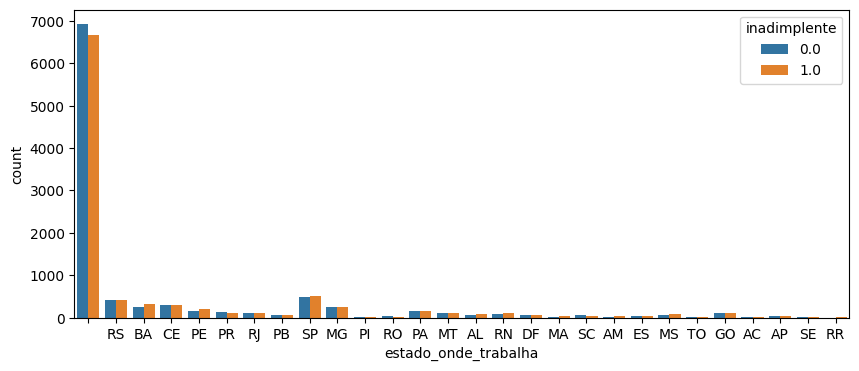

In [30]:
summarize_empty(data, 'estado_onde_trabalha', False)

In [31]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(data['estado_onde_reside'], data['estado_onde_trabalha'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Testando estado_onde_reside x estado_onde_trabalha")
print("Chi-squared:", chi2)
print("p-value:", p)

Testando estado_onde_reside x estado_onde_trabalha
Chi-squared: 201414.01790574496
p-value: 0.0


In [32]:
data.loc[data['estado_onde_nasceu'].str.strip() == '', 'estado_onde_nasceu'] = 'XX'
data = data.drop(columns=['estado_onde_trabalha'])

### 2.2.2 - Código de area telefone residencial e código de area telefone trabalho
- A variável codigo_area_telefone_residencial possui forte correlação com a variável local_onde_reside. Portanto, removei do dataset para evitar redundância.
- Como a variável de codigo_area_telefone_trabalho apresenta alto índice (>50%) de "vazia", será removida.

Contagem de valores únicos: 78
Valores únicos: [' ' '10' '100' '103' '105' '107' '110' '111' '112' '114' '115' '117'
 '118' '119' '12' '120' '122' '123' '124' '125' '126' '13' '14' '15' '16'
 '18' '19' '20' '22' '24' '25' '27' '29' '30' '31' '32' '33' '38' '39' '4'
 '40' '41' '43' '44' '46' '47' '48' '5' '50' '52' '53' '54' '58' '6' '61'
 '62' '66' '67' '68' '69' '7' '71' '72' '73' '74' '75' '76' '77' '81' '84'
 '85' '86' '9' '90' '91' '94' '96' '97']
Contagem de valores vazios: 18186 -> 72.744% dos dados


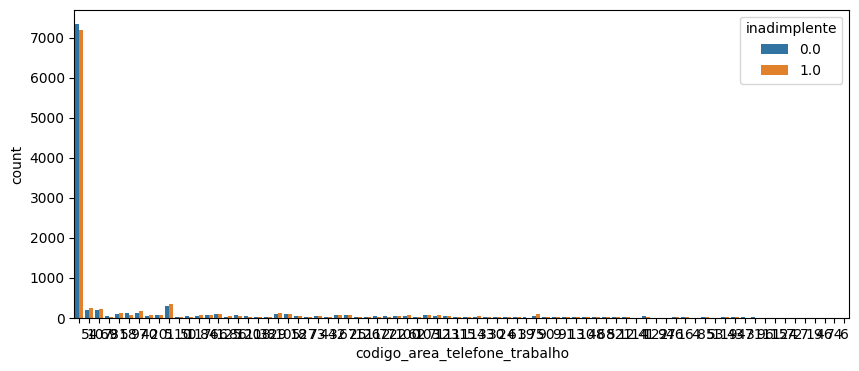

In [33]:
summarize_empty(data, 'codigo_area_telefone_trabalho', False)

Contagem de valores únicos: 87
Valores únicos: [' ' '1' '10' '100' '103' '105' '107' '109' '110' '111' '112' '113' '114'
 '117' '118' '119' '12' '120' '122' '123' '124' '125' '126' '13' '14' '15'
 '16' '17' '18' '2' '20' '22' '24' '25' '27' '29' '30' '31' '32' '33' '35'
 '36' '38' '39' '40' '41' '43' '44' '46' '47' '48' '49' '5' '50' '52' '54'
 '58' '6' '61' '62' '66' '67' '68' '69' '70' '71' '73' '75' '76' '77' '79'
 '80' '81' '82' '83' '84' '85' '86' '89' '9' '90' '91' '93' '95' '97' '98'
 '99']
Contagem de valores vazios: 4353 -> 17.412% dos dados


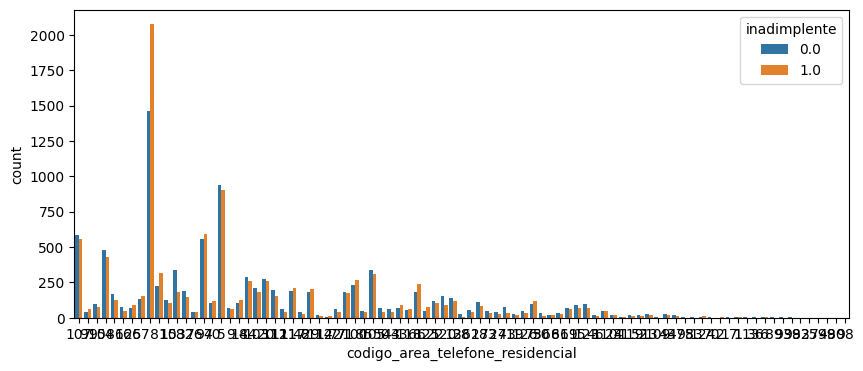

In [34]:
summarize_empty(data, 'codigo_area_telefone_residencial', False)

In [35]:
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(data['local_onde_reside'], data['codigo_area_telefone_residencial'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("Testando local_onde_reside x codigo_area_telefone_residencial")
print("Chi-squared:", chi2)
print("p-value:", p)

Testando local_onde_reside x codigo_area_telefone_residencial
Chi-squared: 1209422.1839480905
p-value: 0.0


In [36]:
data = data.drop(columns=['codigo_area_telefone_trabalho', 'codigo_area_telefone_residencial'])

In [37]:
empty_counts = data.map(lambda x: isinstance(x, str) and x.strip() == '').sum()

filtered_counts = empty_counts[empty_counts > 0]

display(filtered_counts.sort_index())

Series([], dtype: int64)

- Podemos verificar que todas as strings vazias foram removidas.

### 2.3 - Removendo dados desnecessários e falhas

- As colunas que sofreram possível falha na extração e não apresentam variação significativa serão removidas do conjunto de dados, como indicado no dicionário de dados.
- Além disso, como observado na matriz de correlação, as colunas local_onde_reside e local_onde_trabalha são equivalentes. Portanto, manterei apenas local_onde_reside.

In [38]:
data = data.drop(columns=['grau_instrucao', 'possui_telefone_celular', 'qtde_contas_bancarias_especiais', 'local_onde_trabalha'])

### 2.4 - Tratamento de variáveis categóricas
- O tratamento será feito utilizando One-Hot encoding

In [39]:
l = data.columns.to_list()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_solicitante               25000 non-null  int64  
 1   produto_solicitado           25000 non-null  int64  
 2   dia_vencimento               25000 non-null  int64  
 3   forma_envio_solicitacao      25000 non-null  object 
 4   tipo_endereco                25000 non-null  int64  
 5   sexo                         25000 non-null  object 
 6   idade                        25000 non-null  int64  
 7   estado_civil                 25000 non-null  int64  
 8   qtde_dependentes             25000 non-null  int64  
 9   nacionalidade                25000 non-null  int64  
 10  estado_onde_nasceu           25000 non-null  object 
 11  estado_onde_reside           25000 non-null  object 
 12  possui_telefone_residencial  25000 non-null  object 
 13  tipo_residencia 

In [40]:
categorical_columns = ['forma_envio_solicitacao', 'sexo', 'estado_onde_nasceu', 'estado_onde_reside', 
                       'possui_telefone_residencial', 'vinculo_formal_com_empresa', 'possui_telefone_trabalho']

onehot_encoder = OneHotEncoder(drop='first', sparse_output=False) 
encoded_categorical = onehot_encoder.fit_transform(data[categorical_columns])
encoded_categorical_df = pd.DataFrame(encoded_categorical, columns=onehot_encoder.get_feature_names_out(categorical_columns))
data = data.drop(columns=categorical_columns)
data = pd.concat([data, encoded_categorical_df], axis=1)

In [41]:
display(data.head())

,id_solicitante,produto_solicitado,dia_vencimento,tipo_endereco,idade,estado_civil,qtde_dependentes,nacionalidade,tipo_residencia,meses_na_residencia,...,estado_onde_reside_RO,estado_onde_reside_RR,estado_onde_reside_RS,estado_onde_reside_SC,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO,possui_telefone_residencial_Y,vinculo_formal_com_empresa_Y,possui_telefone_trabalho_Y
0,1,1,10,1,85,2,0,1,1.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,1,25,1,38,1,0,1,1.0,5.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,3,1,20,1,37,2,0,1,5.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4,1,20,1,37,1,1,1,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
4,5,7,1,1,51,1,3,1,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


## 2.5 - Normalização das variáveis númericas

- A normalização será feita com StandardScaler

In [42]:
numerical_columns = [
    col for col in data.select_dtypes(include=[np.number]).columns.tolist()
    if col not in onehot_encoder.get_feature_names_out(categorical_columns)
]

In [43]:
for col in numerical_columns:
    print(f'{col}: {data[col].nunique()}')

id_solicitante: 25000
produto_solicitado: 3
dia_vencimento: 6
tipo_endereco: 2
idade: 86
estado_civil: 8
qtde_dependentes: 16
nacionalidade: 3
tipo_residencia: 6
meses_na_residencia: 85
possui_email: 2
renda_mensal_regular: 3475
renda_extra: 333
possui_cartao_visa: 2
possui_cartao_mastercard: 2
possui_cartao_diners: 2
possui_cartao_amex: 2
possui_outros_cartoes: 2
qtde_contas_bancarias: 3
valor_patrimonio_pessoal: 105
possui_carro: 2
meses_no_trabalho: 13
ocupacao: 6
local_onde_reside: 761
inadimplente: 2


In [44]:
numerical_columns = ['qtde_dependentes', 'idade', 'meses_na_residencia', 'renda_mensal_regular', 'renda_extra',
                     'valor_patrimonio_pessoal', 'meses_no_trabalho']

scaler = StandardScaler()
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])

In [45]:
display(data.head())

,id_solicitante,produto_solicitado,dia_vencimento,tipo_endereco,idade,estado_civil,qtde_dependentes,nacionalidade,tipo_residencia,meses_na_residencia,...,estado_onde_reside_RO,estado_onde_reside_RR,estado_onde_reside_RS,estado_onde_reside_SC,estado_onde_reside_SE,estado_onde_reside_SP,estado_onde_reside_TO,possui_telefone_residencial_Y,vinculo_formal_com_empresa_Y,possui_telefone_trabalho_Y
0,1,1,10,1,2.863632,2,-0.539694,1,1.0,0.239814,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2,1,25,1,-0.290053,1,-0.539694,1,1.0,-0.445987,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,3,1,20,1,-0.357153,2,-0.539694,1,5.0,-0.837874,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,4,1,20,1,-0.357153,1,0.277331,1,1.0,-0.837874,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
4,5,7,1,1,0.582243,1,1.911381,1,0.0,-0.837874,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


## 2.6 - Divisão dos dados em treino e teste

In [46]:
data = data.drop(columns=['id_solicitante'])

train = data[:splitting_idx].copy()
train['inadimplente'] = train['inadimplente'].astype(int)
test = data[splitting_idx:].copy()

X = train.drop('inadimplente', axis = 1)
y = train['inadimplente']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Kaggle_test = test.drop('inadimplente', axis = 1)

## 3 - Criação do modelo

### 3.1 - Teste de diferentes modelos

In [47]:
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Histogram Gradient Boosting": HistGradientBoostingClassifier(),
    "SGD Classifier": SGDClassifier()
}

In [48]:
warnings.filterwarnings('ignore', category=ConvergenceWarning)
model_eval = {}
for model_name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy')
    model_eval[model_name] = scores

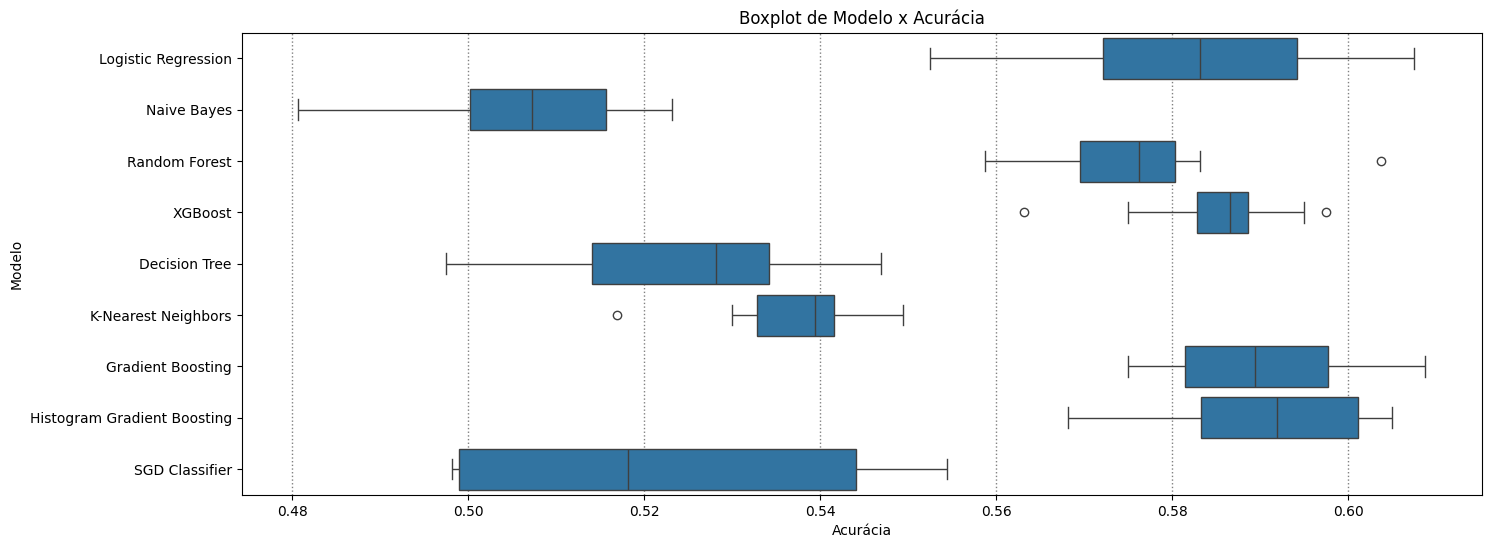

In [49]:
results = pd.DataFrame({
    'Modelo': np.repeat(list(model_eval.keys()), 10),
    'Acurácia': np.concatenate(list(model_eval.values()))
})

plt.figure(figsize=(16, 6))
plt.grid(color='gray', linestyle=':', linewidth=1, zorder=0)
plt.gca().set_axisbelow(True)
sns.boxplot(y='Modelo', x='Acurácia', data=results)
plt.title('Boxplot de Modelo x Acurácia')
plt.show()

- Como o melhor modelo encontrado foi o GradientBoosting, com boa acurácia e baixa dispersão, este será utilizada para a previsão final.

### 3.2 - Otimização de Hiperparâmetros

- Esta parte esta comentada pois a GridSearch demora bastante tempo. Portanto, para evitar uma execução muito longa, deixarei desativada. 
<br>Porém, os resultados são: ```{'learning_rate': 0.2, 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 200, 'subsample': 0.8}```


In [50]:
gdb_clf = GradientBoostingClassifier()

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.2],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 5, 8],
    'min_samples_leaf': [2, 3, 4],
    'subsample':[0.5, 0.8]
}
grid_search = GridSearchCV(estimator=gdb_clf, 
                           param_grid=param_grid, 
                           scoring='accuracy', 
                           cv=5, 
                           verbose=4,
                           n_jobs=-1)
# grid_search.fit(X_train, y_train)

# best_params = grid_search.best_params_
# print("Melhores parâmetros encontrados:", best_params)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Melhores parâmetros encontrados: {'learning_rate': 0.2, 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 200, 'subsample': 0.8}


### 3.3 - Previsão final

In [53]:
best_model = GradientBoostingClassifier(learning_rate=0.2, max_depth=3, 
                                        min_samples_leaf=3, min_samples_split=8, 
                                        n_estimators=200, subsample=0.8)
best_model.fit(X_train, y_train)
predictions = best_model.predict(Kaggle_test)

submission = pd.DataFrame({
    'id_solicitante': id_solicitante_kaggle,
    'inadimplente': predictions
})
submission.to_csv('previsoes_inadimplencia.csv', index=False)